### A Hebbian Learning Network

Part 1: Simulating the input data $\mathbf{x}$ and the target output $\mathbf{y}$

Part 2: Implementing Oja's Learning Rule

Part 3: Implementing Sanger's Rule

Part 4: Training the Network, and visualizing the Loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

### Part 1: Data Simulation

The data matrix is a $d \times N$ matrix, where $d$ is the dimension of each data point, and $N$ is the number of neurons. Each neuron $\mathbf{x}_i$ is drawn from a Gaussian distribution with mean $\mathbf{0}$ and variance $\sigma^2$. The covariance matrix is constructed such that the first $k$ dimensions have higher variance than the remaining dimensions.

$$
\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \sigma^2)
$$

The calculation of the covariance matrix is performed as the expected value of the outer product of the input matrix $\mathbf{x}$:

$$
\mathbf{C} = \frac{1}{N} \mathbf{x} \mathbf{x}^T
$$

### Part 2: Implementation of Oja's rule

Let's start first with the classic Hebbian learning. 

$$
\mathbf{y = w^\top x}
$$

In the regular term, it gonan be $y_i = \sum_{j} w_{ij} x_j$. To avoid the unbounded weight problem, we need to introduce a normalization term. Oja's rule modifies the weight update as follows:

$$
\mathbf{\Delta w \propto yx }
$$

The regular form is $\Delta w_{ij} = \alpha x_j y_i$. The principle is that, if both the input and output neurons have large values, the $w_{ij}$ between the two neurons will be updated more. 

However, the learning rule above has a problem that the weights is not converging; The Oja's rule introduced the normalized term to the equation:

$$
\Delta w = yx - y^2w
$$

In the regular form, it would be $\Delta w_{ij} = y_i x_j - y_i \sum_k w_{kj}^\top x_{kj}$. 

We will build two versions: one is one neuron model; one is multiple neurons model. 



### Input Matrix and Covariance Matrix

In [2]:
number_of_neurons = 2
number_of_samples = 200

def InputMatrix(number_of_neurons, number_of_samples):
    return 
    
def CovarianceMatrix(X, center=True):
    if center:
        X = X - np.mean(X, axis=1, keepdims=True)
    return X @ X.T / number_of_samples


### Model Structure

In [3]:
class HebbianClassic(ABC):
    """
    Base class for linear Hebbian models.

    Conventions:
      - x: shape (n,), single sample (n = input_size)
      - W (self.weights): shape (n, k), columns are neuron weight vectors
      - y = x @ W  -> shape (k,)
    """
    def __init__(self, input_size, output_size, learning_rate=0.01, rng=None):
        if input_size <= 0 or output_size <= 0:
            raise ValueError("input_size and output_size must be positive integers.")
        self.input_size = int(input_size)
        self.output_size = int(output_size)
        self.learning_rate = float(learning_rate)
        self.rng = np.random.default_rng(rng)
        # small random init; columns are neurons
        self.weights = 0.01 * self.rng.standard_normal((self.input_size, self.output_size))


    def forward(self, x):
        """
        x: shape (n,), online learning (one sample)
        returns y: shape (k,)
        """
        x = np.asarray(x, dtype=float).reshape(-1)
        if x.shape[0] != self.input_size:
            raise ValueError(f"x has shape {x.shape}, expected ({self.input_size},)")
        return x @ self.weights  # (k,)

    @abstractmethod
    def step(self, x):
        """
        Perform one online update with sample x.
        Must:
          - compute y = forward(x)
          - update self.weights in-place
          - return y (shape (k,))
        """
        raise NotImplementedError

    def train(self, X, epochs=1, shuffle=True):
        """
        Online training over X for 'epochs' passes.
        X: array-like of shape (N, n)
        """
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.input_size:
            raise ValueError(f"X has shape {X.shape}, expected (N, {self.input_size})")
        N = X.shape[0]
        for ep in range(int(epochs)):
                idx = np.arange(N)
                if shuffle:
                    self.rng.shuffle(idx)
                for t, i in enumerate(idx):
                    y = self.step(X[i])
                    
    # convenience
    @property
    def W(self):
        return self.weights

    def normalize_columns(self, eps=1e-12):
        """Optional: normalize each neuron to unit norm."""
        norms = np.linalg.norm(self.weights, axis=0, keepdims=True) + eps
        self.weights /= norms

    

In [4]:
class Oja1(HebbianClassic):
    """
    Oja's rule for a single neuron (k = 1):
      w <- w + eta * ( y * x - y^2 * w ), where y = w^T x
    Learns the first principal component direction.
    """
    def __init__(self, input_size, learning_rate=0.01, rng=None):
        super().__init__(input_size=input_size, output_size=1,
                         learning_rate=learning_rate, rng=rng)

    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)
        y = float(self.forward(x))                # scalar
        # w is (n,), stored as column 0 of weights
        w = self.weights[:, 0]
        w += self.learning_rate * (y * x - (y * y) * w)
        self.weights[:, 0] = w
        return np.array([y])


In [5]:
class OjaNetwork(HebbianClassic):
    """
    Multi-output Oja "subspace rule":
      W <- W + eta * ( x y^T - W (y y^T) ),  y = W^T x
    Learns the PC subspace spanned by top-k PCs (order not enforced).
    """
    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)           # (n,)
        y = self.forward(x)                                  # (k,)
        # ΔW = eta * ( x y^T - W (y y^T) )
        yyT = np.outer(y, y)                                 # (k, k)
        self.weights += self.learning_rate * (
            np.outer(x, y) - self.weights @ yyT
        )
        return y

In [6]:
class SangerNetwork(HebbianClassic):
    """
    Sanger's rule / Generalized Hebbian Algorithm (GHA):
      For j = 0..k-1:
        w_j <- w_j + eta * y_j * ( x - sum_{i<=j} y_i * w_i )
    Produces ordered PCs (PC1, then PC2, ...).
    """
    def step(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)           # (n,)
        y = self.forward(x)                                  # (k,)
        # Update each column with progressively larger projection subspace
        for j in range(self.output_size):
            # proj_j = sum_{i<=j} y_i * w_i  = W[:, :j+1] @ y[:j+1]
            proj_j = self.weights[:, :j+1] @ y[:j+1]         # (n,)
            self.weights[:, j] += self.learning_rate * y[j] * (x - proj_j)
        return y

### Usage

In [7]:
mu1 = 0.0
std1 = 1.0
mu2 = 0.0
std2 = 0.5
orientation = np.pi / 4.0#numpy.random.random() * numpy.pi
nb_samples = 200

def gauss_distrib(theta, mu1, std1, mu2, std2, nb_samples):
    samples = np.zeros((nb_samples,2));
    for i in range(nb_samples):
        u1 = np.random.random();
        u2 = np.random.random();
        T1 = np.sqrt(-2 * np.log(u1)) * np.cos(2*np.pi*u2);
        T2 = np.sqrt(-2 * np.log(u1)) * np.sin(2*np.pi*u2);
        
        samples[i,0] = mu1 +  (std1*T1 * np.cos(theta) - std2*T2 * np.sin(theta));
        samples[i,1] = mu2 +  (std1*T1 * np.sin(theta) + std2*T2 * np.cos(theta));	

    return samples


# We precompute the samples
samples = gauss_distrib(orientation, mu1,std1,mu2,std2,nb_samples)
samples[:,0] -= np.mean(samples[:,0])
samples[:,1] -= np.mean(samples[:,1])


In [8]:
def pc1_from_data(X):
    """
    X must be mean-centered (N, d).
    Returns the first principal component as a unit vector (d,).
    """
    C = np.cov(X, rowvar=False)
    vals, vecs = np.linalg.eigh(C)
    pc1 = vecs[:, np.argsort(vals)[-1]]  # largest eigenvalue
    pc1 /= np.linalg.norm(pc1) + 1e-12
    return pc1

def cosine_alignment(u, v):
    """|cos(theta)| between two vectors u, v."""
    u = u / (np.linalg.norm(u) + 1e-12)
    v = v / (np.linalg.norm(v) + 1e-12)
    return float(abs(u @ v))

def alignment_over_epochs(model, X, epochs, shuffle=True, match="best"):
    """
    Train 'model' for 'epochs' epochs, and record alignment to true PC1 after each epoch.

    Parameters
    ----------
    model : HebbianClassic (Oja1, OjaNetwork, or SangerNetwork)
    X     : (N, d) mean-centered data
    epochs: int
    shuffle: bool
    match : 'first' or 'best'
        - 'first' : align PC1 with the model's first column (good for Sanger, which orders PCs)
        - 'best'  : pick the column with the highest |cos| to PC1 (good for Oja multi / unordered)

    Returns
    -------
    align_hist : list of floats, length = epochs
    """
    X = np.asarray(X, float)
    pc1 = pc1_from_data(X)
    align_hist = []

    for _ in range(int(epochs)):
        model.train(X, epochs=1, shuffle=shuffle)  # one epoch at a time
        W = model.W                                # (d, k)
        if W.ndim == 1:
            w = W
            align_hist.append(cosine_alignment(w, pc1))
        else:
            if match == "first":
                w = W[:, 0]
                align_hist.append(cosine_alignment(w, pc1))
            else:  # 'best'
                # choose the column most aligned with PC1
                cols = W.shape[1]
                cands = [cosine_alignment(W[:, j], pc1) for j in range(cols)]
                align_hist.append(max(cands))
    return align_hist

In [9]:
X = samples

# X is your data (N, d); IMPORTANT: center it first
X = X - X.mean(axis=0, keepdims=True)

# 1) Oja single-neuron
oja1 = Oja1(input_size=X.shape[1], learning_rate=0.005, rng=0)
hist_oja1 = alignment_over_epochs(oja1, X, epochs=20, shuffle=True, match="first")


/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_14032/3043652209.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = float(self.forward(x))                # scalar


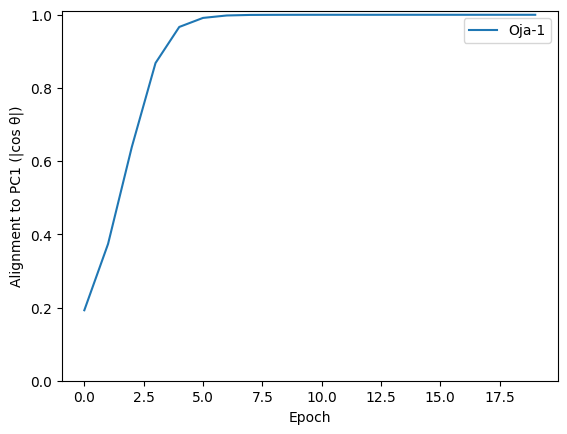

In [10]:
plt.plot(hist_oja1, label="Oja-1")
plt.xlabel("Epoch")
plt.ylabel("Alignment to PC1 (|cos θ|)")
plt.ylim(0, 1.01)
plt.legend()
plt.show()